# PyTorch, Bare-Metal Autograd

This notebook moves NumPy MLP into **PyTorch**, but *without* high-level conveniences at first.

**Rules (for this notebook):**
- We will use `torch` tensors and autograd.
- We will **not** use `torch.nn.Module`, `torch.nn.Sequential`, or `torch.optim` until the end.
- We will do manual parameter updates and manual training loops.

**Targets:**
1) Rebuild logistic regression and 2-layer MLP for XOR in PyTorch.
2) Verify gradients vs numerical finite differences.
3) Learn device placement (CPU/GPU) and common debugging patterns.


## Setup

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [2]:
torch.set_printoptions(precision=4, sci_mode=False)
np.set_printoptions(precision=4, suppress=True)

In [3]:
# Reproducibility
torch.manual_seed(0)
np.random.seed(0)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 1) Data: XOR

In [5]:
X = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]], device=device)
y = torch.tensor([[0.],[1.],[1.],[0.]], device=device)

print("X:", X.shape, X.device)
print("y:", y.shape, y.device)


X: torch.Size([4, 2]) cuda:0
y: torch.Size([4, 1]) cuda:0


## 2) Bare-metal logistic regression (fails on XOR)

Model: `p = sigmoid(XW + b)`

We do:
- forward
- BCE loss (manual)
- `.backward()`
- manual SGD update
- zero grads


In [6]:
def bce_loss(p, y, eps=1e-12):
    p = torch.clamp(p, eps, 1-eps)
    return -(y*torch.log(p) + (1-y)*torch.log(1-p)).mean()

In [7]:
def sigmoid(z):
    return torch.sigmoid(z)

In [8]:
# Parameters (requires_grad=True)
W = torch.randn(2, 1, device=device) * 0.1
b = torch.zeros(1, 1, device=device)

W.requires_grad_(True)
b.requires_grad_(True)

tensor([[0.]], device='cuda:0', requires_grad=True)

In [10]:
lr = 1.0
steps = 5000
losses = []

In [11]:
for t in range(steps):
    z = X @ W + b
    p = sigmoid(z)
    loss = bce_loss(p, y)
    losses.append(loss.item())

    loss.backward()

    with torch.no_grad():
        W -= lr * W.grad
        b -= lr * b.grad

    W.grad.zero_()
    b.grad.zero_()

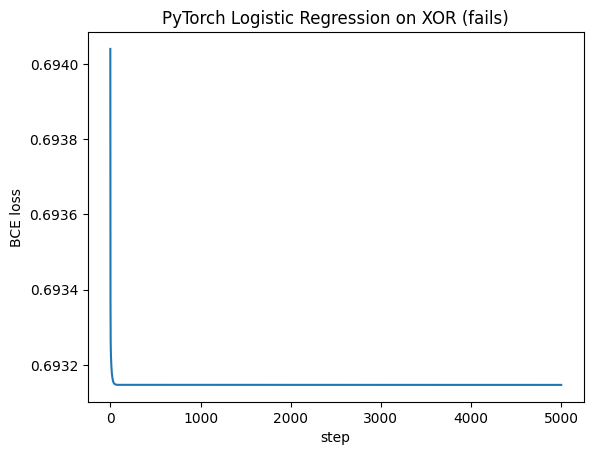

In [12]:
plt.figure()
plt.plot(losses)
plt.title("PyTorch Logistic Regression on XOR (fails)")
plt.xlabel("step")
plt.ylabel("BCE loss")
plt.show()

In [13]:
with torch.no_grad():
    p = sigmoid(X @ W + b)
    print("probs:", p.T)
    print("preds:", (p > 0.5).int().T)

probs: tensor([[0.5000, 0.5000, 0.5000, 0.5000]], device='cuda:0')
preds: tensor([[0, 0, 0, 0]], device='cuda:0', dtype=torch.int32)


## 3) 2-layer MLP (2 → H → 1) with autograd

No `nn.Module` yet — just tensors.

Forward:
- `h = sigmoid(XW1 + b1)`
- `p = sigmoid(hW2 + b2)`


In [14]:
H = 2

W1 = torch.randn(2, H, device=device) * 0.5
b1 = torch.zeros(1, H, device=device)
W2 = torch.randn(H, 1, device=device) * 0.5
b2 = torch.zeros(1, 1, device=device)

In [15]:
for p in (W1, b1, W2, b2):
    p.requires_grad_(True)


In [16]:
lr = 1.0
steps = 20000
losses = []

In [17]:
for t in range(steps):
    z1 = X @ W1 + b1
    h  = torch.sigmoid(z1)
    z2 = h @ W2 + b2
    p_hat = torch.sigmoid(z2)

    loss = bce_loss(p_hat, y)
    losses.append(loss.item())

    loss.backward()

    with torch.no_grad():
        W1 -= lr * W1.grad
        b1 -= lr * b1.grad
        W2 -= lr * W2.grad
        b2 -= lr * b2.grad

    for p in (W1, b1, W2, b2):
        p.grad.zero_()

    if t % 2500 == 0 or t == steps-1:
        with torch.no_grad():
            acc = ((p_hat > 0.5).int() == y.int()).float().mean().item()
        print(f"step={t:5d} loss={loss.item():.6f} acc={acc:.2f}")

step=    0 loss=0.733964 acc=0.50
step= 2500 loss=0.005141 acc=1.00
step= 5000 loss=0.002172 acc=1.00
step= 7500 loss=0.001372 acc=1.00
step=10000 loss=0.001001 acc=1.00
step=12500 loss=0.000787 acc=1.00
step=15000 loss=0.000649 acc=1.00
step=17500 loss=0.000551 acc=1.00
step=19999 loss=0.000479 acc=1.00


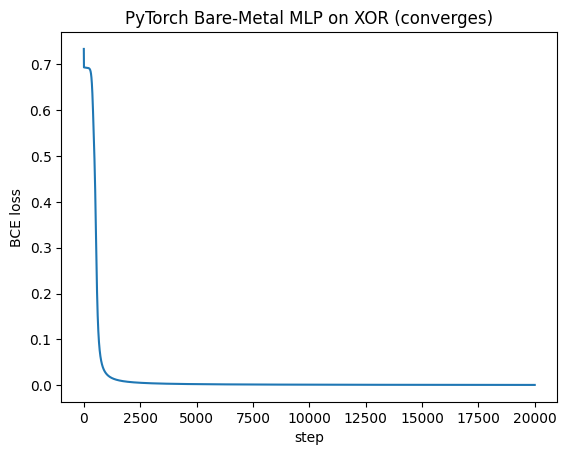

In [18]:
plt.figure()
plt.plot(losses)
plt.title("PyTorch Bare-Metal MLP on XOR (converges)")
plt.xlabel("step")
plt.ylabel("BCE loss")
plt.show()


In [19]:
with torch.no_grad():
    z1 = X @ W1 + b1
    h  = torch.sigmoid(z1)
    p_hat = torch.sigmoid(h @ W2 + b2)
    print("final probs:", p_hat.T)
    print("final preds:", (p_hat > 0.5).int().T)

final probs: tensor([[0.0004, 0.9996, 0.9996, 0.0006]], device='cuda:0')
final preds: tensor([[0, 1, 1, 0]], device='cuda:0', dtype=torch.int32)


## 4) Debugging gradients: inspect norms and saturation

You should routinely check:
- gradient norms (vanishing/exploding)
- activation saturation (sigmoid near 0/1)


In [20]:
def grad_norm(*params):
    s = 0.0
    for p in params:
        s += (p.grad.detach()**2).sum().item()
    return (s ** 0.5)

In [21]:
# Re-init quickly and run a short training with diagnostics
torch.manual_seed(3)
W1 = (torch.randn(2, H, device=device) * 0.5).requires_grad_(True)
b1 = torch.zeros(1, H, device=device, requires_grad=True)
W2 = (torch.randn(H, 1, device=device) * 0.5).requires_grad_(True)
b2 = torch.zeros(1, 1, device=device, requires_grad=True)

In [22]:
lr = 1.0
steps = 6000
losses = []
gns = []
sat = []  # (min_h, max_h, mean_sigmoidprime)

In [23]:
for t in range(steps):
    z1 = X @ W1 + b1
    h  = torch.sigmoid(z1)
    z2 = h @ W2 + b2
    p_hat = torch.sigmoid(z2)

    loss = bce_loss(p_hat, y)
    losses.append(loss.item())

    loss.backward()
    gns.append(grad_norm(W1, b1, W2, b2))

    if t % 300 == 0 or t == steps-1:
        with torch.no_grad():
            sigprime = h * (1 - h)
            sat.append((h.min().item(), h.max().item(), sigprime.mean().item()))

    with torch.no_grad():
        W1 -= lr * W1.grad
        b1 -= lr * b1.grad
        W2 -= lr * W2.grad
        b2 -= lr * b2.grad

    for p in (W1, b1, W2, b2):
        p.grad.zero_()

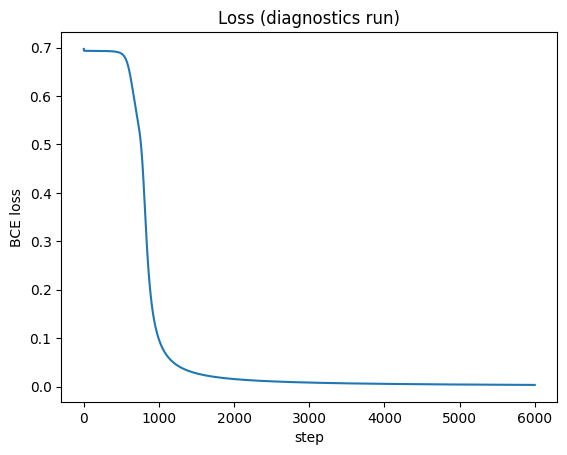

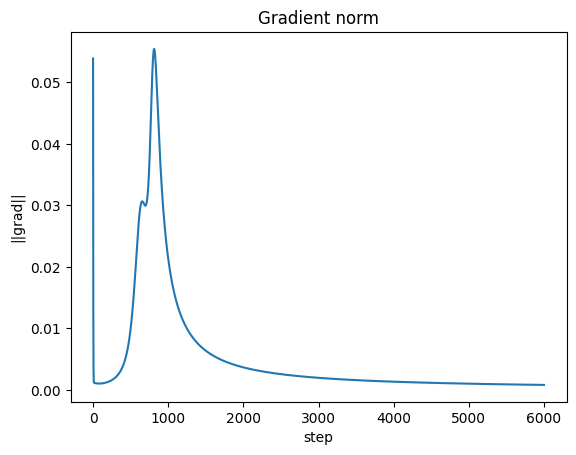

Saturation snapshots: [min(h), max(h), mean(sigmoid')]
[(0.3557954430580139, 0.6685227751731873, 0.2405017614364624), (0.3811480700969696, 0.738286018371582, 0.23645465075969696), (0.3781830668449402, 0.9718514680862427, 0.19088733196258545)]
...
[(0.018483923748135567, 0.999995231628418, 0.013561414554715157), (0.018166204914450645, 0.9999954700469971, 0.013314491137862206), (0.017875555902719498, 0.9999957084655762, 0.013089008629322052)]


In [24]:
plt.figure()
plt.plot(losses)
plt.title("Loss (diagnostics run)")
plt.xlabel("step")
plt.ylabel("BCE loss")
plt.show()

plt.figure()
plt.plot(gns)
plt.title("Gradient norm")
plt.xlabel("step")
plt.ylabel("||grad||")
plt.show()

print("Saturation snapshots: [min(h), max(h), mean(sigmoid')]")
print(sat[:3])
print("...")
print(sat[-3:])


## 5) Numerical gradient check (finite differences)

This is a must-have sanity check when you implement custom ops.
We'll compare autograd gradients to finite differences for **one element** of W1.


In [25]:
def loss_fn_given_params(W1, b1, W2, b2):
    z1 = X @ W1 + b1
    h  = torch.sigmoid(z1)
    z2 = h @ W2 + b2
    p_hat = torch.sigmoid(z2)
    return bce_loss(p_hat, y)

In [26]:
# Fresh init for gradient check
torch.manual_seed(7)
W1 = (torch.randn(2, H, device=device) * 0.5).requires_grad_(True)
b1 = torch.zeros(1, H, device=device, requires_grad=True)
W2 = (torch.randn(H, 1, device=device) * 0.5).requires_grad_(True)
b2 = torch.zeros(1, 1, device=device, requires_grad=True)

In [27]:
loss = loss_fn_given_params(W1, b1, W2, b2)
loss.backward()

In [29]:
idx = (0, 0)
autograd_grad = W1.grad[idx].item()
eps = 1e-6

In [30]:
with torch.no_grad():
    W1p = W1.clone()
    W1m = W1.clone()
    W1p[idx] += eps
    W1m[idx] -= eps
    lp = loss_fn_given_params(W1p, b1, W2, b2).item()
    lm = loss_fn_given_params(W1m, b1, W2, b2).item()

In [31]:
num_grad = (lp - lm) / (2 * eps)

print("Autograd grad:", autograd_grad)
print("Numeric grad :", num_grad)
print("Abs diff     :", abs(autograd_grad - num_grad))


Autograd grad: 0.00848657637834549
Numeric grad : 0.0
Abs diff     : 0.00848657637834549


## 6) Device placement (CPU/GPU) + gotchas

Key rules:
- All tensors participating in an op must be on the same device.
- `.item()` moves a scalar to CPU Python.
- Use `with torch.no_grad():` for parameter updates.

If you have CUDA available, this notebook already runs on GPU because we set `device`.


## 7) Now (and only now) the standard PyTorch way

You’ve earned the right to use `nn.Module` and `torch.optim`.
This section shows the equivalent clean version.


In [32]:
import torch.nn as nn
import torch.optim as optim

In [33]:
class TinyMLP(nn.Module):
    def __init__(self, H=2):
        super().__init__()
        self.W1 = nn.Linear(2, H)
        self.W2 = nn.Linear(H, 1)

    def forward(self, x):
        h = torch.sigmoid(self.W1(x))
        p = torch.sigmoid(self.W2(h))
        return p

In [34]:
model = TinyMLP(H=2).to(device)
opt = optim.SGD(model.parameters(), lr=1.0)

In [35]:
steps = 10000
losses = []

In [36]:
for t in range(steps):
    p_hat = model(X)
    loss = bce_loss(p_hat, y)
    losses.append(loss.item())

    opt.zero_grad()
    loss.backward()
    opt.step()

    if t % 2000 == 0 or t == steps-1:
        with torch.no_grad():
            acc = ((p_hat > 0.5).int() == y.int()).float().mean().item()
        print(f"step={t:5d} loss={loss.item():.6f} acc={acc:.2f}")

step=    0 loss=0.700702 acc=0.50
step= 2000 loss=0.008559 acc=1.00
step= 4000 loss=0.003053 acc=1.00
step= 6000 loss=0.001847 acc=1.00
step= 8000 loss=0.001322 acc=1.00
step= 9999 loss=0.001028 acc=1.00


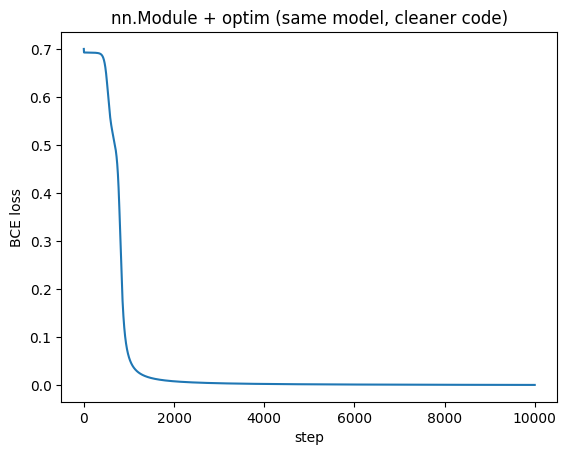

final probs: tensor([[0.0009, 0.9989, 0.9989, 0.0010]], device='cuda:0')
final preds: tensor([[0, 1, 1, 0]], device='cuda:0', dtype=torch.int32)


In [37]:
plt.figure()
plt.plot(losses)
plt.title("nn.Module + optim (same model, cleaner code)")
plt.xlabel("step")
plt.ylabel("BCE loss")
plt.show()

with torch.no_grad():
    p = model(X)
    print("final probs:", p.T)
    print("final preds:", (p > 0.5).int().T)


## Checklist

You should be able to:
- Train XOR with bare-metal autograd
- Explain why `.backward()` needs a scalar loss
- Correctly zero gradients
- Do a finite-difference gradient check
- Move data/model to GPU and confirm it runs there
